In [2]:
from pathlib import Path

# Change this to your desired location
project_path = Path(r"D:\Projects\Sales-Performance-Dashboard")

# Create main project folder
project_path.mkdir(parents=True, exist_ok=True)

# Create subfolders
folders = [
    "Dataset",
    "Notebook",
    "Dashboard",
    "Report",
    "Images"
]

for folder in folders:
    (project_path / folder).mkdir(exist_ok=True)

# Create README.md
(project_path / "README.md").touch(exist_ok=True)

print("✅ Project created successfully!")
print("Location:", project_path)

✅ Project created successfully!
Location: D:\Projects\Sales-Performance-Dashboard


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
import pandas as pd

df = pd.read_csv(r"D:\projects\Sales-Performance-Dashboard\Dataset\archive (3)\SampleSuperstore.csv")

In [11]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [13]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [14]:
df.shape

(9994, 13)

In [15]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(17)

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(9977, 13)

In [20]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [21]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [22]:
df["Region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [23]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [24]:
df["Segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [25]:
df.to_csv(r"D:\projects\Sales-Performance-Dashboard\Dataset\Cleaned_Superstore.csv", index=False)

In [26]:
total_sales = df["Sales"].sum()
print(f"Total Sales: {total_sales:.2f}")

Total Sales: 2296195.59


In [27]:
total_profit = df["Profit"].sum()
print(f"Total Profit: {total_profit:.2f}")

Total Profit: 286241.42


In [28]:
total_quantity = df["Quantity"].sum()
print(f"Total Quantity Sold: {total_quantity}")

Total Quantity Sold: 37820


In [29]:
average_sales = df["Sales"].mean()
print(f"Average Sales: {average_sales:.2f}")

Average Sales: 230.15


In [30]:
average_profit = df["Profit"].mean()
print(f"Average Profit: {average_profit:.2f}")

Average Profit: 28.69


In [31]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


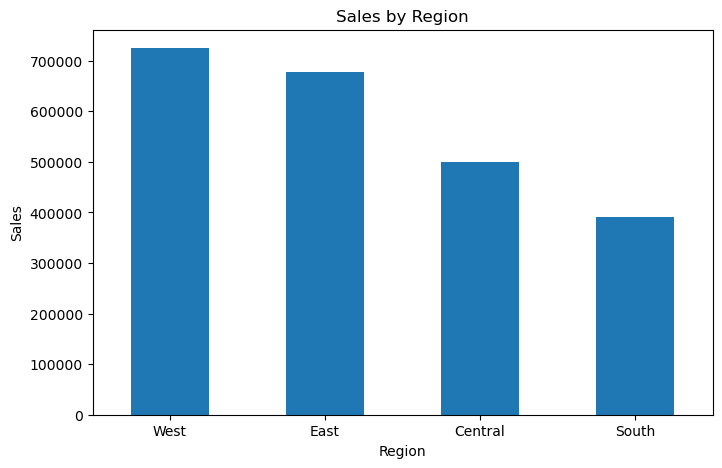

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [33]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


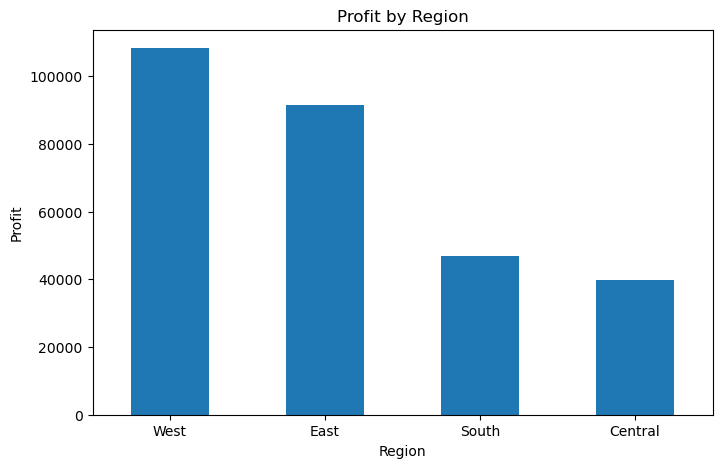

In [34]:
plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [35]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


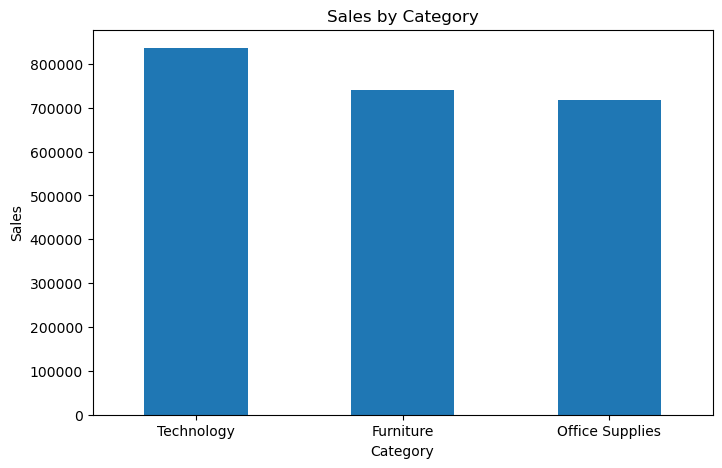

In [36]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [37]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


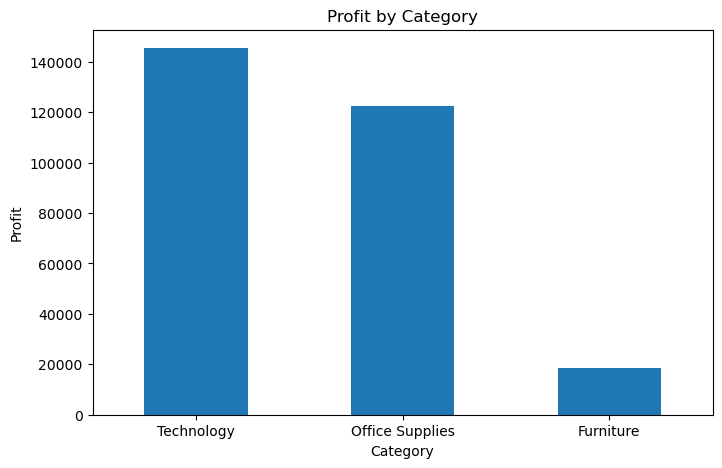

In [38]:
plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [39]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_states)

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


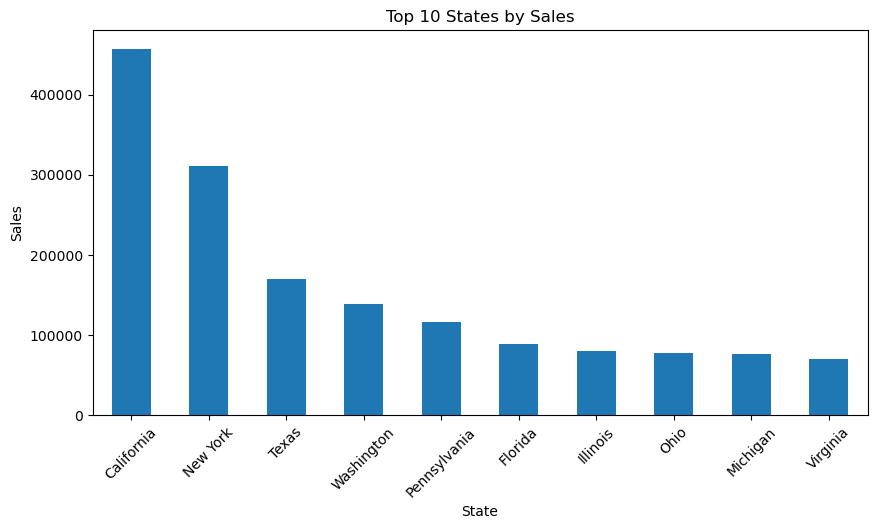

In [40]:
plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [41]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_cities)

City
New York City    256319.0410
Los Angeles      175831.9010
Seattle          119460.2820
San Francisco    112577.1720
Philadelphia     109061.4610
Houston           64441.2564
Chicago           48535.9770
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


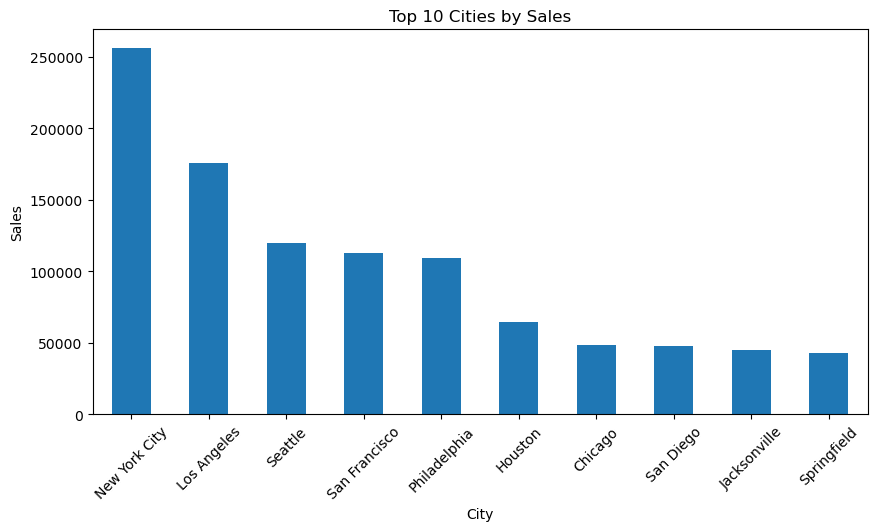

In [42]:
plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [43]:
top_profit_states = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

print(top_profit_states)

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


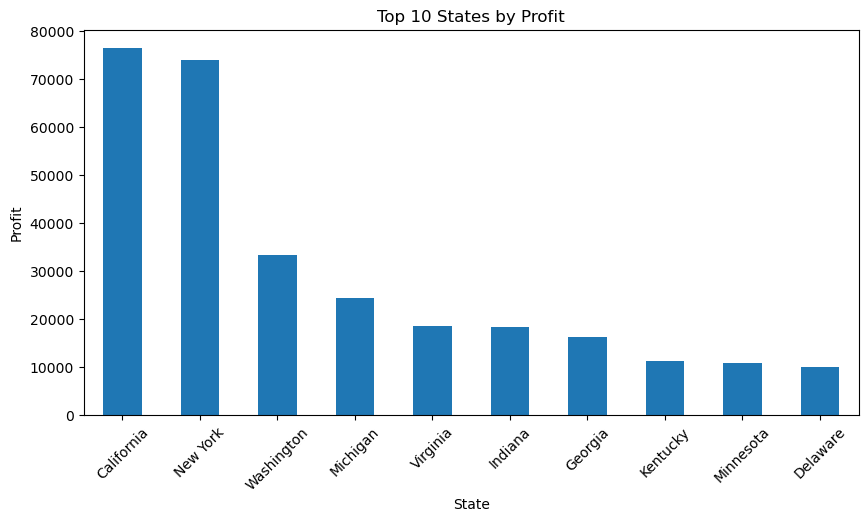

In [44]:
plt.figure(figsize=(10,5))
top_profit_states.plot(kind="bar")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [45]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

print(segment_sales)

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


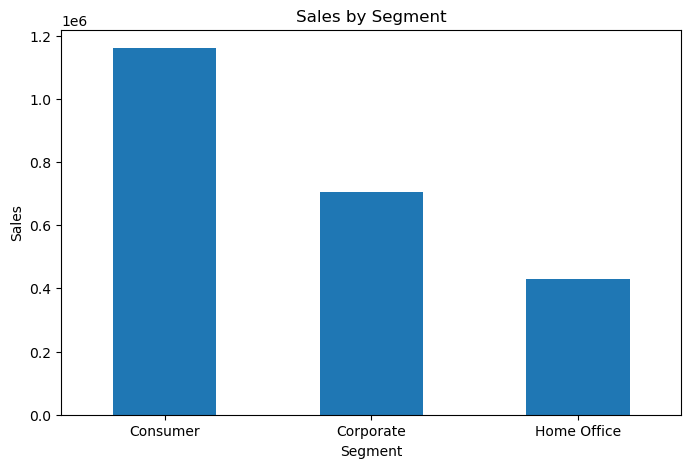

In [46]:
plt.figure(figsize=(8,5))
segment_sales.plot(kind="bar")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

In [47]:
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

print(segment_profit)

Segment
Consumer       134007.4413
Corporate       91954.9798
Home Office     60279.0015
Name: Profit, dtype: float64


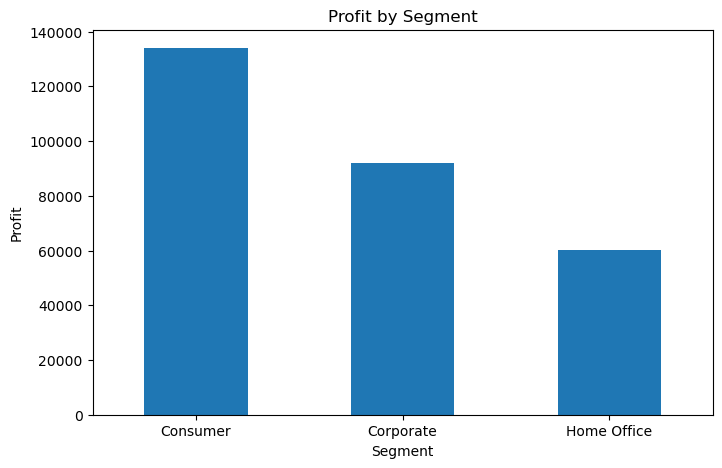

In [48]:
plt.figure(figsize=(8,5))
segment_profit.plot(kind="bar")

plt.title("Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

In [49]:
quantity_category = df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

print(quantity_category)

Category
Office Supplies    22861
Furniture           8020
Technology          6939
Name: Quantity, dtype: int64


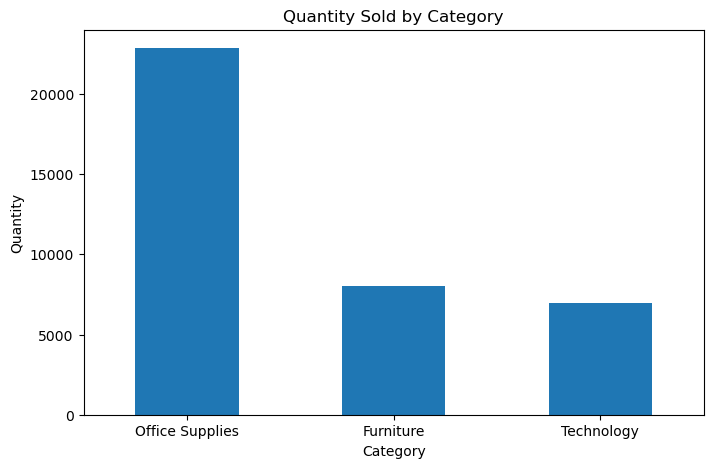

In [50]:
plt.figure(figsize=(8,5))
quantity_category.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.xticks(rotation=0)

plt.show()

In [51]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

print(ship_sales)

Ship Mode
Standard Class    1.357316e+06
Second Class      4.591770e+05
First Class       3.513805e+05
Same Day          1.283217e+05
Name: Sales, dtype: float64


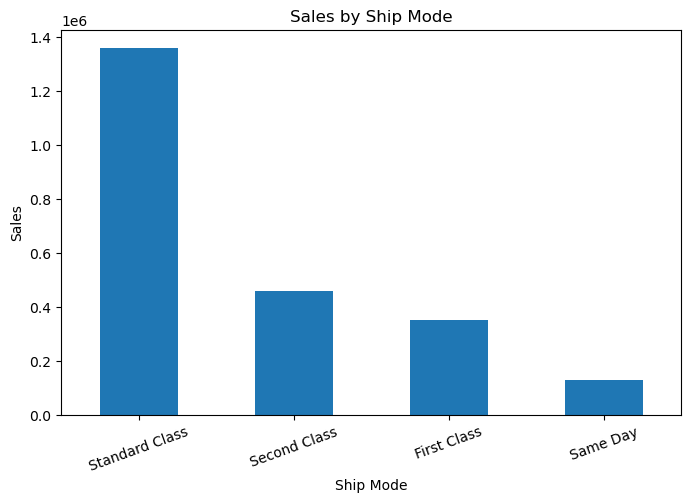

In [52]:
plt.figure(figsize=(8,5))
ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")

plt.xticks(rotation=20)

plt.show()

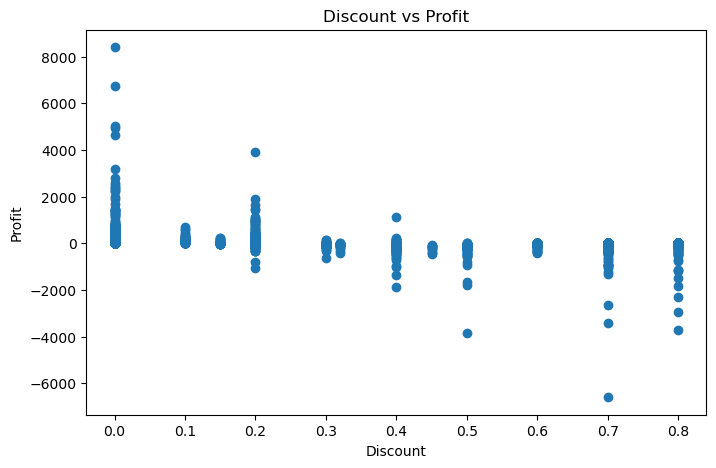

In [53]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [54]:
top_subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_subcategory)

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


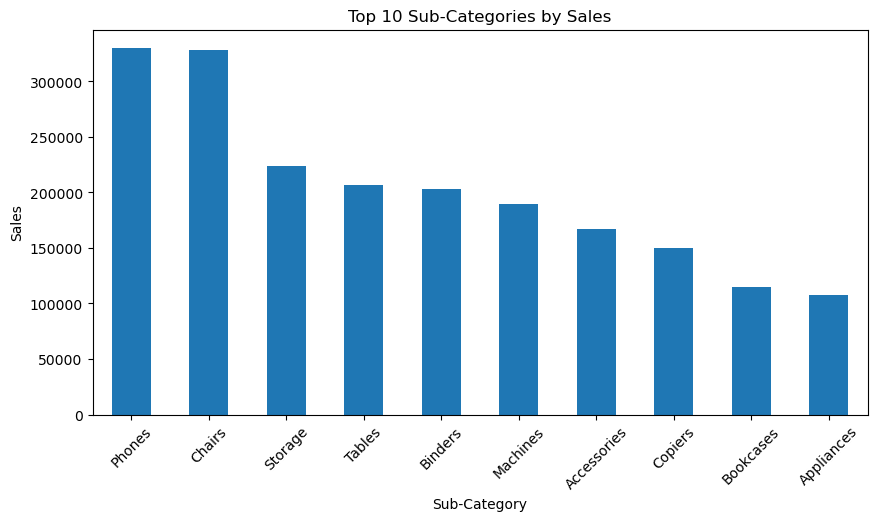

In [55]:
plt.figure(figsize=(10,5))
top_subcategory.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [56]:
top_sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(10)

print(top_sub_profit)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Name: Profit, dtype: float64


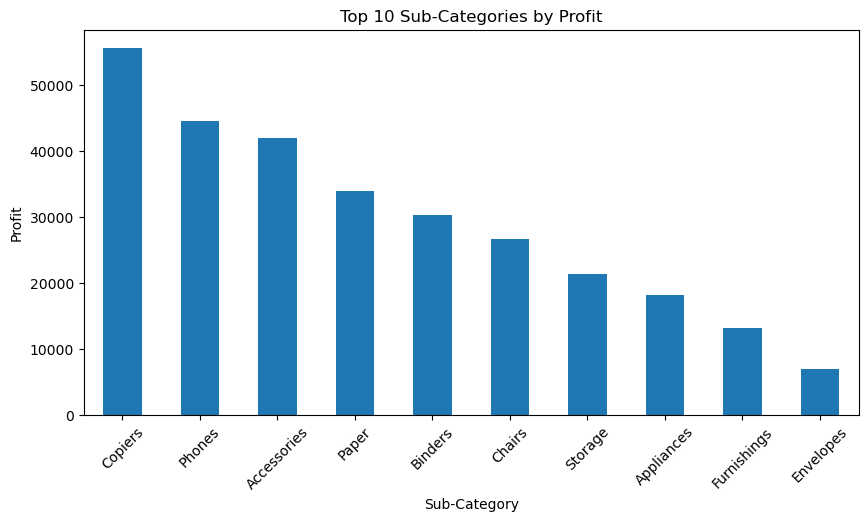

In [57]:
plt.figure(figsize=(10,5))
top_sub_profit.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [58]:
df.to_csv(
    r"D:\projects\Sales-Performance-Dashboard\Dataset\Cleaned_Superstore.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
